<a href="https://colab.research.google.com/github/gokadagaya/fittrack-project--2601920-/blob/main/eda_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv")

Task 1: Distribution Analysis Using Histograms

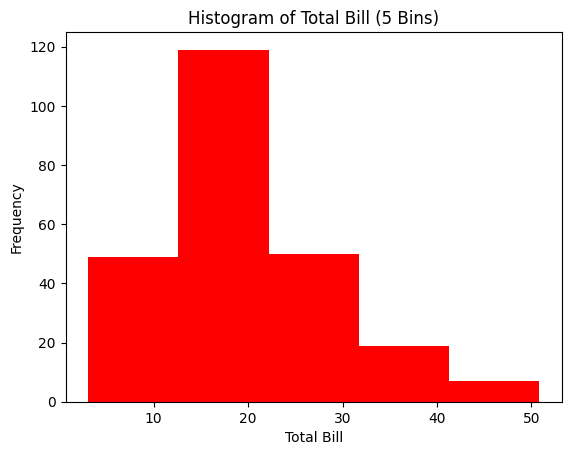

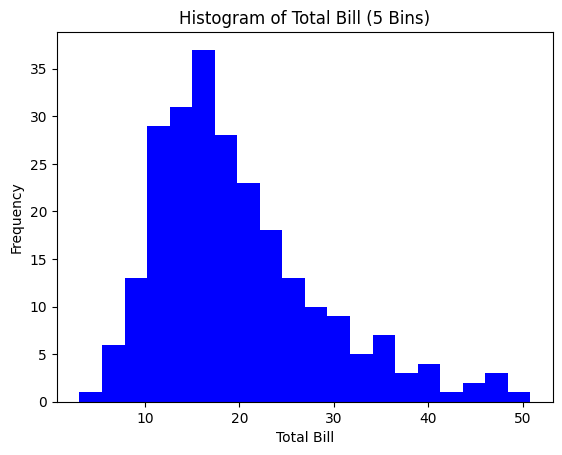

In [9]:
import matplotlib.pyplot as plt

plt.hist(df["total_bill"],bins=5, color="red")
plt.xlabel("Total Bill")
plt.ylabel("Frequency")
plt.title("Histogram of Total Bill (5 Bins)")
plt.show()

plt.hist(df["total_bill"],bins=20, color="blue")
plt.xlabel("Total Bill")
plt.ylabel("Frequency")
plt.title("Histogram of Total Bill (5 Bins)")
plt.show()


1)What does the distribution of total_bill look like — is it symmetric, left-skewed, or right-skewed?

Distribution of total_bill: Right-skewed-->positive skew

2)How does changing the number of bins affect your ability to interpret the distribution?

• 5 bins: No much details, just a genereal overview
• 20 bins: More detailed view of how the values are distributed

Task 2: Outlier Detection Using Box Plots

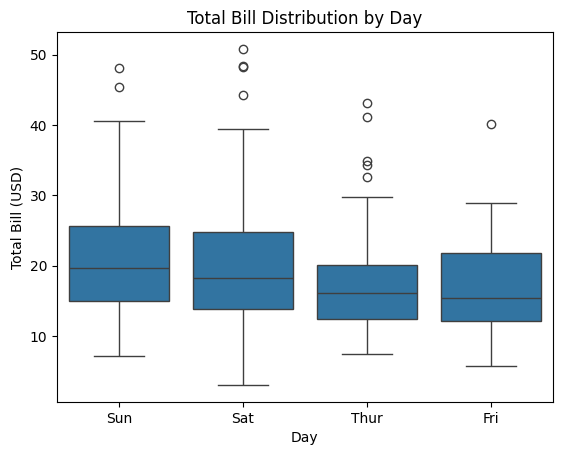

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="day", y="total_bill", data=df)

plt.xlabel("Day")
plt.ylabel("Total Bill (USD)")
plt.title("Total Bill Distribution by Day")

plt.show()

In [12]:
df.groupby("day")["total_bill"].quantile([0.25,0.75])

day       
Fri   0.25    12.0950
      0.75    21.7500
Sat   0.25    13.9050
      0.75    24.7400
Sun   0.25    14.9875
      0.75    25.5975
Thur  0.25    12.4425
      0.75    20.1550
Name: total_bill, dtype: float64

1)On which day does the median total bill appear highest?
on Sunday

2)Identify at least one day that appears to have outliers. Calculate the IQR for that day manually using df.groupby() and quantile(), and verify whether the points you identified qualify as outliers using the standard rule: Q1 − 1.5×IQR and Q3 + 1.5×IQR.


Thursday appears to have several outliers in the box plot. Using the IQR method, Q1 ≈ 12.44 and Q3 ≈ 19.81, giving an IQR of 7.37. The upper bound is approximately 30.87. Any total_bill greater than this value is considered an outlier. Several Thursday values above 30.87 (around 32–43 USD) therefore qualify as outliers.

Task 3: Multi-Variable Comparison Using an Interactive Plot

In [13]:
import plotly.express as px

fig = px.scatter(
    df,
    x="total_bill",
    y="tip",
    color="time",
    hover_data=["day","size"],
    title="Total Bill vs Tip"
)

fig.show()

1)Does there appear to be a relationship between total_bill and tip? Describe what you observe.
Yes, there is a clear positive relationship. As the total bill increases, the tip generally increases as well.

2)Do Lunch and Dinner transactions differ noticeably in their tipping patterns? What does the color separation reveal?

The color separation typically shows that Dinner transactions dominate the higher bill ranges. Dinner points usually appear further to the right side of the plot, meaning higher total bills and larger tips. Lunch transactions tend to cluster in the lower bill range, with smaller tips. This indicates that dinner meals often involve higher spending and therefore higher tips compared to lunch.


3)Identify one specific data point (visible via hover) that you find interesting or unusual, and briefly explain why.

unusual pattern is a few transactions where the total bill is around $30 but the tip is close to $1–$2, which is lower than expected compared to other points with similar bill values.



